In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

csv_path = Path("../data/raw/atp_tennis.csv")
df = pd.read_csv(csv_path)

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Surface"] = df["Surface"].astype(str).str.strip()
df["Round"] = df["Round"].astype(str).str.strip()

df.head()


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,Escude N.,40,655,-1,-1,-1.0,-1.0,6-7 7-5 6-3
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,Federer R.,87,65,-1,-1,-1.0,-1.0,1-6 4-6
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,Fromberg R.,81,198,-1,-1,-1.0,-1.0,7-6 5-7 6-4


In [2]:
def to_long_format(df: pd.DataFrame) -> pd.DataFrame:
    p1 = pd.DataFrame({
        "date": df["Date"],
        "tournament": df["Tournament"],
        "series": df["Series"],
        "court": df["Court"],
        "surface": df["Surface"],
        "round": df["Round"],
        "best_of": df["Best of"],

        "player": df["Player_1"],
        "opponent": df["Player_2"],
        "is_win": (df["Winner"] == df["Player_1"]).astype(int),

        "player_rank": df["Rank_1"],
        "opponent_rank": df["Rank_2"],
        "player_points": df["Pts_1"],
        "opponent_points": df["Pts_2"],
        "player_odds": df["Odd_1"],
        "opponent_odds": df["Odd_2"],

        "score": df["Score"]
    })

    p2 = pd.DataFrame({
        "date": df["Date"],
        "tournament": df["Tournament"],
        "series": df["Series"],
        "court": df["Court"],
        "surface": df["Surface"],
        "round": df["Round"],
        "best_of": df["Best of"],

        "player": df["Player_2"],
        "opponent": df["Player_1"],
        "is_win": (df["Winner"] == df["Player_2"]).astype(int),

        "player_rank": df["Rank_2"],
        "opponent_rank": df["Rank_1"],
        "player_points": df["Pts_2"],
        "opponent_points": df["Pts_1"],
        "player_odds": df["Odd_2"],
        "opponent_odds": df["Odd_1"],

        "score": df["Score"]
    })

    long_df = pd.concat([p1, p2], ignore_index=True)
    long_df["season"] = long_df["date"].dt.year

    return long_df

In [3]:
long_df = to_long_format(df)

print(long_df.shape)
long_df.head()


(133362, 18)


,date,tournament,series,court,surface,round,best_of,player,opponent,is_win,player_rank,opponent_rank,player_points,opponent_points,player_odds,opponent_odds,score,season
0,2000-01-03,Australian Hardcourt Championships,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,1,63,77,-1,-1,-1.0,-1.0,6-4 6-2,2000
1,2000-01-03,Australian Hardcourt Championships,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,0,56,5,-1,-1,-1.0,-1.0,3-6 3-6,2000
2,2000-01-03,Australian Hardcourt Championships,International,Outdoor,Hard,1st Round,3,Escude N.,Baccanello P.,1,40,655,-1,-1,-1.0,-1.0,6-7 7-5 6-3,2000
3,2000-01-03,Australian Hardcourt Championships,International,Outdoor,Hard,1st Round,3,Knippschild J.,Federer R.,0,87,65,-1,-1,-1.0,-1.0,1-6 4-6,2000
4,2000-01-03,Australian Hardcourt Championships,International,Outdoor,Hard,1st Round,3,Fromberg R.,Woodbridge T.,1,81,198,-1,-1,-1.0,-1.0,7-6 5-7 6-4,2000


In [4]:
long_df[long_df["player"].isin(["Alcaraz C.", "Sinner J."])] \
    .groupby("player")["is_win"] \
    .agg(matches="count", win_rate="mean")


,matches,win_rate
player,,
Alcaraz C.,313,0.811502
Sinner J.,374,0.794118


In [5]:
x = long_df.copy()

# Season Range 
x = x[x["season"].between(2020, 2025)]

# Filter Matches by Surface Type
x["surface"] = x["surface"].astype(str).str.strip()
x = x[x["surface"].isin(["Hard", "Clay", "Grass"])]

print(x.shape)
x.head()


(27808, 18)


,date,tournament,series,court,surface,round,best_of,player,opponent,is_win,player_rank,opponent_rank,player_points,opponent_points,player_odds,opponent_odds,score,season
52777,2020-01-06,Qatar Exxon Mobil Open,ATP250,Outdoor,Hard,1st Round,3,Mannarino A.,Bublik A.,0,43,55,1111,919,1.72,2.00,3-6 4-6,2020
52778,2020-01-06,Qatar Exxon Mobil Open,ATP250,Outdoor,Hard,1st Round,3,Moutet C.,Sandgren T.,1,81,68,638,803,1.57,2.25,7-6 6-4,2020
52779,2020-01-06,Qatar Exxon Mobil Open,ATP250,Outdoor,Hard,1st Round,3,Andujar P.,Verdasco F.,0,64,49,867,1025,3.75,1.25,4-6 3-6,2020
52780,2020-01-06,Qatar Exxon Mobil Open,ATP250,Outdoor,Hard,1st Round,3,Bedene A.,Ymer M.,1,58,76,905,681,1.83,1.83,3-6 6-4 6-3,2020
52781,2020-01-06,Qatar Exxon Mobil Open,ATP250,Outdoor,Hard,1st Round,3,Barrere G.,Chardy J.,0,83,54,636,920,2.50,1.50,3-6 6-3 3-6,2020


In [6]:
# Calculate Ranking Difference Between Player and Opponent
x["rank_diff"] = x["player_rank"] - x["opponent_rank"]

# Identify Underdog Matches Using Betting Odds
x["is_underdog"] = np.where(
    (x["player_odds"].notna()) & (x["opponent_odds"].notna()) & (x["player_odds"] > x["opponent_odds"]),
    1, 0
)

# Best of 5 Matches
x["best5"] = np.where(x["best_of"] == 5, 1, 0)

x[["rank_diff","is_underdog","best5"]].describe()


,rank_diff,is_underdog,best5
count,27808.00000,27808.000000,27808.000000
mean,0.00000,0.486659,0.201669
std,152.17868,0.499831,0.401253
min,-4911.00000,0.000000,0.000000
25%,-41.00000,0.000000,0.000000
50%,0.00000,0.000000,0.000000
75%,41.00000,1.000000,0.000000
max,4911.00000,1.000000,1.000000


In [7]:
features_agg = (
    x.groupby(["player", "season", "surface"], as_index=False)
     .agg(
         matches=("is_win", "size"),
         win_rate=("is_win", "mean"),
         avg_player_rank=("player_rank", "mean"),
         avg_opponent_rank=("opponent_rank", "mean"),
         avg_rank_diff=("rank_diff", "mean"),
         avg_player_points=("player_points", "mean"),
         avg_opponent_points=("opponent_points", "mean"),
         avg_player_odds=("player_odds", "mean"),
         avg_opponent_odds=("opponent_odds", "mean"),
         underdog_matches=("is_underdog", "sum"),
         best_of_5_rate=("best5", "mean"),
     )
)

features_agg.head()


,player,season,surface,matches,win_rate,avg_player_rank,avg_opponent_rank,avg_rank_diff,avg_player_points,avg_opponent_points,avg_player_odds,avg_opponent_odds,underdog_matches,best_of_5_rate
0,Added D.,2025,Hard,1,0.0,204.0,156.0,48.0,276.0,386.0,2.75,1.440,1,0.0
1,Agamenone F.,2022,Clay,5,0.6,140.0,66.0,74.0,399.8,1281.4,4.20,1.332,5,0.2
2,Ajdukovic D.,2021,Clay,2,0.5,275.0,126.5,148.5,216.0,951.0,2.60,1.665,1,0.0
3,Ajdukovic D.,2022,Clay,1,0.0,276.0,38.0,238.0,175.0,1121.0,5.50,1.140,1,0.0
4,Ajdukovic D.,2023,Clay,1,0.0,299.0,287.0,12.0,178.0,188.0,2.50,1.530,1,0.0


In [8]:
underdog_wr = (
    x[x["is_underdog"] == 1]
    .groupby(["player", "season", "surface"], as_index=False)["is_win"]
    .mean()
    .rename(columns={"is_win": "underdog_win_rate"})
)

features_agg = features_agg.merge(underdog_wr, on=["player","season","surface"], how="left")
features_agg["underdog_win_rate"] = features_agg["underdog_win_rate"].fillna(0.0)

features_agg.head()


,player,season,surface,matches,win_rate,avg_player_rank,avg_opponent_rank,avg_rank_diff,avg_player_points,avg_opponent_points,avg_player_odds,avg_opponent_odds,underdog_matches,best_of_5_rate,underdog_win_rate
0,Added D.,2025,Hard,1,0.0,204.0,156.0,48.0,276.0,386.0,2.75,1.440,1,0.0,0.0
1,Agamenone F.,2022,Clay,5,0.6,140.0,66.0,74.0,399.8,1281.4,4.20,1.332,5,0.2,0.6
2,Ajdukovic D.,2021,Clay,2,0.5,275.0,126.5,148.5,216.0,951.0,2.60,1.665,1,0.0,0.0
3,Ajdukovic D.,2022,Clay,1,0.0,276.0,38.0,238.0,175.0,1121.0,5.50,1.140,1,0.0,0.0
4,Ajdukovic D.,2023,Clay,1,0.0,299.0,287.0,12.0,178.0,188.0,2.50,1.530,1,0.0,0.0


In [9]:
features_agg = features_agg[features_agg["matches"] >= 15].reset_index(drop=True)
print(features_agg.shape)
features_agg.head()


(622, 15)


,player,season,surface,matches,win_rate,avg_player_rank,avg_opponent_rank,avg_rank_diff,avg_player_points,avg_opponent_points,avg_player_odds,avg_opponent_odds,underdog_matches,best_of_5_rate,underdog_win_rate
0,Alcaraz C.,2021,Hard,27,0.629630,80.444444,67.444444,13.000000,1025.629630,1974.296296,2.168519,2.325926,10,0.222222,0.7
1,Alcaraz C.,2022,Clay,30,0.866667,11.200000,53.000000,-41.800000,3815.666667,2364.133333,1.272000,6.142667,1,0.166667,1.0
2,Alcaraz C.,2022,Hard,31,0.806452,10.677419,32.322581,-21.645161,4112.290323,2256.870968,1.337742,4.280000,1,0.290323,0.0
3,Alcaraz C.,2023,Clay,28,0.892857,1.785714,71.500000,-69.714286,6722.142857,1591.964286,1.118929,9.688929,0,0.214286,0.0
4,Alcaraz C.,2023,Hard,35,0.742857,1.485714,33.200000,-31.714286,8498.714286,2732.857143,1.275143,6.955143,2,0.142857,0.0


In [10]:
features_agg[
    features_agg["player"].isin(["Alcaraz C.", "Sinner J."])
].sort_values(["player","season","surface"])


,player,season,surface,matches,win_rate,avg_player_rank,avg_opponent_rank,avg_rank_diff,avg_player_points,avg_opponent_points,avg_player_odds,avg_opponent_odds,underdog_matches,best_of_5_rate,underdog_win_rate
0,Alcaraz C.,2021,Hard,27,0.629630,80.444444,67.444444,13.000000,1025.629630,1974.296296,2.168519,2.325926,10,0.222222,0.700000
1,Alcaraz C.,2022,Clay,30,0.866667,11.200000,53.000000,-41.800000,3815.666667,2364.133333,1.272000,6.142667,1,0.166667,1.000000
2,Alcaraz C.,2022,Hard,31,0.806452,10.677419,32.322581,-21.645161,4112.290323,2256.870968,1.337742,4.280000,1,0.290323,0.000000
3,Alcaraz C.,2023,Clay,28,0.892857,1.785714,71.500000,-69.714286,6722.142857,1591.964286,1.118929,9.688929,0,0.214286,0.000000
4,Alcaraz C.,2023,Hard,35,0.742857,1.485714,33.200000,-31.714286,8498.714286,2732.857143,1.275143,6.955143,2,0.142857,0.000000
5,Alcaraz C.,2024,Hard,31,0.741935,2.354839,55.580645,-53.225806,7816.129032,2662.870968,1.195161,10.101290,1,0.193548,1.000000
6,Alcaraz C.,2025,Clay,22,0.954545,2.500000,50.636364,-48.136364,7836.363636,2716.136364,1.244091,8.853636,2,0.272727,1.000000
7,Alcaraz C.,2025,Hard,41,0.853659,2.170732,45.634146,-43.463415,8881.707317,2454.780488,1.190976,9.906829,2,0.268293,0.500000
534,Sinner J.,2020,Hard,19,0.631579,59.789474,60.789474,-1.000000,962.631579,1610.473684,1.701053,3.004737,5,0.157895,0.200000
535,Sinner J.,2021,Clay,15,0.600000,18.933333,45.866667,-26.933333,2461.866667,3912.666667,2.116667,3.732667,4,0.266667,0.000000


In [11]:
feature_cols = [
    "win_rate",
    "avg_player_rank",
    "avg_opponent_rank",
    "avg_rank_diff",
    "avg_player_points",
    "avg_opponent_points",
    "avg_player_odds",
    "avg_opponent_odds",
    "underdog_win_rate",
    "best_of_5_rate",
]


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

X = features_agg[feature_cols].copy()

# # Convert Features to Numeric Values
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

sim_matrix = cosine_similarity(X_scaled)

In [13]:
def top_similar_players(player_name: str, season: int, surface: str, top_n: int = 10) -> pd.DataFrame:
    mask = (
        (features_agg["player"] == player_name) &
        (features_agg["season"] == season) &
        (features_agg["surface"] == surface)
    )
    idx = features_agg.index[mask]

    if len(idx) == 0:
        return pd.DataFrame({
            "error": [f"No row found for {player_name} in {season} on {surface}. Try another season/surface or lower matches threshold."]
        })

    i = idx[0]

    scores = pd.Series(sim_matrix[i], index=features_agg.index).sort_values(ascending=False)

    out = features_agg.loc[scores.index, ["player", "season", "surface", "matches", "win_rate"]].copy()
    out["similarity"] = scores.values
    out = out[out["player"] != player_name].head(top_n).reset_index(drop=True)
    return out


In [14]:
top_similar_players("Alcaraz C.", 2024, "Hard", 10)


,player,season,surface,matches,win_rate,similarity
0,Rublev A.,2021,Hard,41,0.658537,0.922525
1,Medvedev D.,2020,Hard,30,0.766667,0.900574
2,Nadal R.,2022,Hard,30,0.800000,0.895742
3,Djokovic N.,2023,Clay,15,0.800000,0.887499
4,Sinner J.,2024,Hard,52,0.942308,0.885988
5,Medvedev D.,2021,Hard,44,0.840909,0.879666
6,Rune H.,2023,Clay,20,0.800000,0.876225
7,Zverev A.,2024,Hard,46,0.760870,0.835542
8,Nadal R.,2020,Hard,18,0.777778,0.827421
9,De Minaur A.,2024,Hard,36,0.694444,0.821670


In [15]:
top_similar_players("Sinner J.", 2024, "Hard", 10)


,player,season,surface,matches,win_rate,similarity
0,Medvedev D.,2021,Hard,44,0.840909,0.978388
1,Zverev A.,2024,Hard,46,0.760870,0.973495
2,Alcaraz C.,2025,Hard,41,0.853659,0.973187
3,Zverev A.,2022,Clay,18,0.777778,0.952101
4,Tsitsipas S.,2021,Hard,38,0.710526,0.949207
5,Rublev A.,2021,Hard,41,0.658537,0.945949
6,Zverev A.,2021,Hard,38,0.815789,0.937689
7,Medvedev D.,2023,Hard,59,0.796610,0.931027
8,Alcaraz C.,2025,Clay,22,0.954545,0.931007
9,Nadal R.,2021,Clay,22,0.863636,0.930750


In [16]:
PLAYER = "Alcaraz C."
SEASON = 2025
SURFACE = "Hard"
TOP_N = 10


In [17]:
features_agg[
    (features_agg["player"] == PLAYER) &
    (features_agg["season"] == SEASON) &
    (features_agg["surface"] == SURFACE)
][["player","season","surface","matches","win_rate"]]


,player,season,surface,matches,win_rate
7,Alcaraz C.,2025,Hard,41,0.853659


In [18]:
topN = top_similar_players(PLAYER, SEASON, SURFACE, TOP_N)
topN


,player,season,surface,matches,win_rate,similarity
0,Sinner J.,2024,Hard,52,0.942308,0.973187
1,Medvedev D.,2021,Hard,44,0.840909,0.960378
2,Sinner J.,2025,Hard,40,0.975000,0.955271
3,Djokovic N.,2020,Hard,27,0.888889,0.947707
4,Zverev A.,2024,Hard,46,0.760870,0.935881
5,Rublev A.,2021,Hard,41,0.658537,0.932454
6,Djokovic N.,2023,Hard,37,0.945946,0.921966
7,Nadal R.,2021,Clay,22,0.863636,0.918502
8,Tsitsipas S.,2021,Hard,38,0.710526,0.911546
9,Nadal R.,2020,Hard,18,0.777778,0.904608


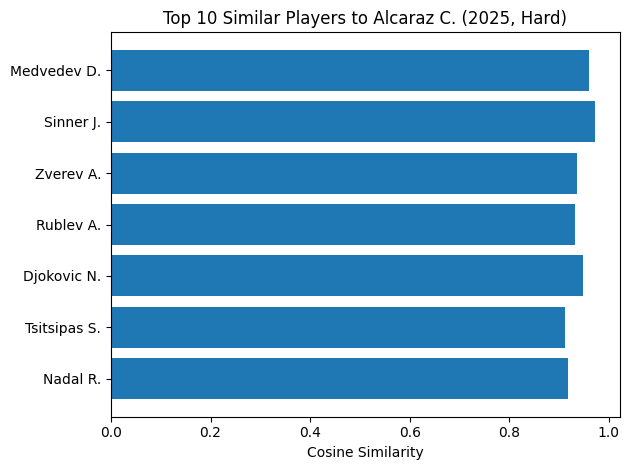

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(topN["player"][::-1], topN["similarity"][::-1])
plt.xlabel("Cosine Similarity")
plt.title(f"Top {TOP_N} Similar Players to {PLAYER} (2025, Hard)")
plt.tight_layout()
plt.show()


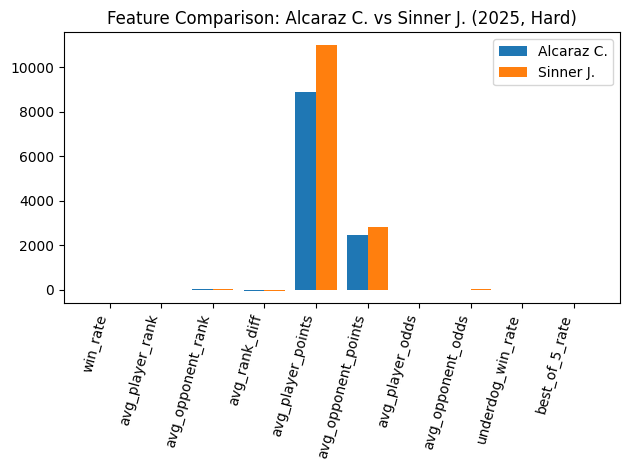

In [20]:
target_row = features_agg[
    (features_agg["player"] == PLAYER) &
    (features_agg["season"] == SEASON) &
    (features_agg["surface"] == SURFACE)
].iloc[0]

# Most Similar Player
peer_name = topN.loc[0, "player"]
peer_row = features_agg[
    (features_agg["player"] == peer_name) &
    (features_agg["season"] == SEASON) &
    (features_agg["surface"] == SURFACE)
].iloc[0]

comp = pd.DataFrame({
    "feature": feature_cols,
    PLAYER: [target_row[f] for f in feature_cols],
    peer_name: [peer_row[f] for f in feature_cols],
})

plt.figure()
x = range(len(comp))
plt.bar([i-0.2 for i in x], comp[PLAYER], width=0.4, label=PLAYER)
plt.bar([i+0.2 for i in x], comp[peer_name], width=0.4, label=peer_name)
plt.xticks(list(x), comp["feature"], rotation=75, ha="right")
plt.title(f"Feature Comparison: {PLAYER} vs {peer_name} (2025, Hard)")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
OUT = Path("../outputs/tables")
OUT.mkdir(parents=True, exist_ok=True)

df.to_csv(OUT / "matches_raw.csv", index=False)
long_df.to_csv(OUT / "player_matches.csv", index=False)
features_agg.to_csv(OUT / "player_features.csv", index=False)
